# Quickstart

This notebook walks through the core lazycogs workflow for opening an array in the native CRS and grid of the underlying assets.

In [1]:
from pathlib import Path

import rustac
from pyproj import Transformer

import lazycogs

## Step 1: Define your area of interest

In this example we will define an AOI in epsg:4326 coordinates for an initial STAC search, then use the returned items to define our array's CRS and resolution.

In [2]:
bbox_4326 = (-152.02, 60.90, -149.22, 61.66)

## Step 2: Search a STAC API and cache results

Use `rustac` to search a STAC API and write the results to a local geoparquet file. lazycogs uses this file as its spatial index — it never calls the STAC API again after this step.

The cell checks whether the file already exists so re-running the notebook doesn't re-fetch.

In [3]:
PARQUET = "data/alaska_summer_2025.parquet"

if not Path(PARQUET).exists():
    Path(PARQUET).parent.mkdir(exist_ok=True)
    await rustac.search_to(
        PARQUET,
        href="https://earth-search.aws.element84.com/v1",
        collections=["sentinel-2-c1-l2a"],
        datetime="2025-07-01/2025-08-31",
        bbox=bbox_4326,
        limit=100,
    )

print(f"Using {PARQUET}")

Using data/alaska_summer_2025.parquet


Look at a sample item to get its projection info

In [4]:
sample_item = rustac.search_sync(
    PARQUET,
    bbox=bbox_4326,
    max_items=1,
)[0]

for key, val in sample_item["properties"].items():
    if "proj" in key:
        print(key, val)

for key, val in sample_item["assets"]["red"].items():
    if "proj" in key:
        print(key, val)

proj:epsg 32605
proj:centroid {'lat': 60.78191, 'lon': -151.45783}
proj:shape [10980, 10980]
proj:transform [10, 0, 499980, 0, -10, 6800040]


Define the CRS and a bbox that is snapped to the Sentinel 2 L2A pixel grid for this UTM Zone.

In [5]:
dst_crs = f"epsg:{sample_item['properties']['proj:epsg']}"

transformer = Transformer.from_crs("epsg:4326", dst_crs, always_xy=True)
dst_bbox = lazycogs.align_bbox(
    affine=sample_item["assets"]["red"]["proj:transform"],
    bbox=transformer.transform_bounds(*bbox_4326),
)
print(dst_bbox)

(551890.0, 6752040.0, 705010.0, 6842120.0)


## Step 3: Open the lazy DataArray

`lazycogs.open()` is nearly instant — it reads the geoparquet metadata to build the coordinate arrays but does not touch any COG files. The default behavior is to create a single time coordinate for each day but this can be adjusted with the `time_period` argument.

In [6]:
store = lazycogs.store_for(PARQUET, skip_signature=True)

da = lazycogs.open(
    PARQUET,
    bbox=dst_bbox,
    crs=dst_crs,
    resolution=10.0,
    bands=["red", "green", "blue", "nir"],
    store=store,
)

da

<xarray.DataArray (band: 4, time: 48, y: 9008, x: 15312)> Size: 106GB
[26482655232 values with dtype=float32]
Coordinates:
  * band         (band) <U5 80B 'red' 'green' 'blue' 'nir'
  * time         (time) datetime64[s] 384B 2025-07-02 2025-07-03 ... 2025-08-31
  * y            (y) float64 72kB 6.842e+06 6.842e+06 ... 6.752e+06 6.752e+06
  * x            (x) float64 122kB 5.519e+05 5.519e+05 ... 7.05e+05 7.05e+05
    spatial_ref  int64 8B 0
Indexes:
  ┌ x        RasterIndex (crs=EPSG:32605)
  └ y
Attributes:
    grid_mapping:            spatial_ref
    zarr_conventions:        [{'name': 'spatial:', 'uuid': '689b58e2-cf7b-45e...
    spatial:transform:       [10.0, 0.0, 551890.0, 0.0, -10.0, 6842120.0]
    spatial:transform_type:  affine
    spatial:registration:    pixel
    proj:code:               EPSG:32605
    _stac_backend:           MultiBandStacBackendArray(bands=['red', 'green',...
    _stac_time_coords:       2025-07-02 … 2025-08-31 (n=48)

The DataArray has dimensions `(band, time, y, x)`. The `time` coordinate lists each day that has at least one matching STAC item. The `band` coordinate lists the assets that were selected (defaults to all assets where `rel="data"`).

No pixel data has been read yet. The DataArray is backed by a `LazilyIndexedArray` that fires reads on demand.

## Step 4: Extract a point time series

Use `.sel()` to extract values at a single location. lazycogs queries the geoparquet for only the COGs that contain this point and reads a single pixel window from each.

In [7]:
da.sel(x=606892, y=6790774, method="nearest").isel(time=slice(0, 3)).compute()

<xarray.DataArray (band: 4, time: 3)> Size: 48B
array([[1299., 1349.,    0.],
       [1744., 1820.,    0.],
       [1307., 1455.,    0.],
       [7024., 7192.,    0.]], dtype=float32)
Coordinates:
  * band         (band) <U5 80B 'red' 'green' 'blue' 'nir'
  * time         (time) datetime64[s] 24B 2025-07-02 2025-07-03 2025-07-04
    x            float64 8B 6.069e+05
    y            float64 8B 6.791e+06
    spatial_ref  int64 8B 0
Attributes:
    grid_mapping:            spatial_ref
    zarr_conventions:        [{'name': 'spatial:', 'uuid': '689b58e2-cf7b-45e...
    spatial:transform:       [10.0, 0.0, 551890.0, 0.0, -10.0, 6842120.0]
    spatial:transform_type:  affine
    spatial:registration:    pixel
    proj:code:               EPSG:32605
    _stac_backend:           MultiBandStacBackendArray(bands=['red', 'green',...
    _stac_time_coords:       2025-07-02 … 2025-08-31 (n=48)

## Step 5: Extract a small spatial subset

Use `.sel()` with slices to extract a spatial region. Only the COGs that intersect this bounding box are fetched.

In [8]:
subset = da.sel(
    x=slice(612650, 622627),
    y=slice(6796718, 6791106),
).isel(time=0)

# you can load the data asynchronously with load_async
_ = await subset.load_async()

Plot the array as a false-color composite

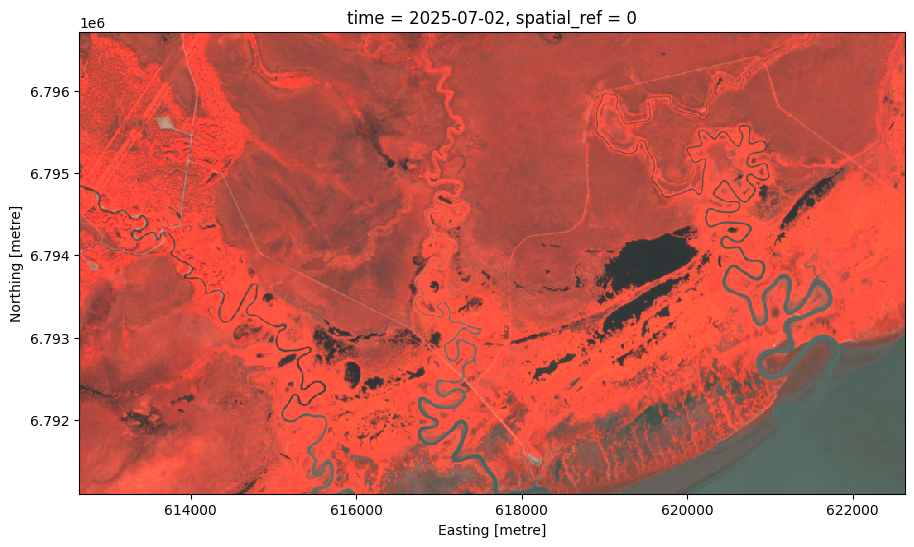

In [9]:
subset.sel(band=["nir", "green", "blue"]).plot.imshow(
    rgb="band",
    vmin=0,
    vmax=5000,
    size=6,
    aspect=subset.shape[2] / subset.shape[1],
)

## What's next
- **[STAC item search guide](../../guides/stac-search/)** - control which STAC items are included
- **[Mosaic methods guide](../../guides/mosaic-methods/)** - control how overlapping scenes are merged
- **[Temporal grouping guide](../../guides/temporal-grouping/)** - composite by week, month, or custom periods
- **[Inspecting read plans](../explain/)** - understand what DuckDB queries and COG reads will fire before computing
- **[Cloud storage guide](../../guides/cloud-storage/)** - understand how to use `obstore` for access to data in cloud storage
- **[Chunking strategies and parallelism](../../guides/chunking/)** - understand strategies for chunking lazycogs arrays in space and time